In [1]:
# preamble
using Revise
using Pkg; Pkg.activate(".")

using Dates
using Statistics
using Rotations
using Interpolations
using DSP
using FFTW
using NCDatasets
using JLD2
using Printf
using Distributions

include("./read_lidar.jl")
using .read_lidar
using .read_lidar.stare
using .read_vecnav: read_vecnav_dict
import .chunks
read_stare_time  = Main.chunks.read_stare_time
read_stare_chunk = Main.chunks.read_stare_chunk
fit_offset = Main.chunks.fit_offset

include("./timing_lidar.jl")
using .timing_lidar
include("./readers.jl")
using .NoaaDas: cat_dicts
# using MAT

using PyPlot
using PyCall
using PyCall: PyObject

# PyObject method interprets Array{Union{T,Missing}} as a
# numpy masked array.
# This allows for plotting with missing values.
function PyCall.PyObject(a::Array{Union{T,Missing},N}) where {T,N}
    numpy_ma = PyCall.pyimport("numpy").ma
    pycall(numpy_ma.array, Any, coalesce.(a,zero(T)), mask=ismissing.(a))
end

  Activating project at `~/Projects/lidar/ASTRAL2024`


In [2]:
# function library with utility functions,  functions for subsetting, for displacements, and for structure functions

# utility functions
pd = permutedims
m2n(x) = ismissing(x) ? NaN : x
good(x) = !ismissing(x) & isfinite(x)

"""
    binavg(y, x, b; f=identity, w=y->1)
Bin average y(x) in bins b of coordinate x.
Skip missing by passing the optional function arguments
f(y) = ismissing(y) ? 0 : y;   w(y) = !ismissing(y)
"""
function binavg(y, x, b; f=identity, w=y->1)
    a = zeros(length(b))
    c = zeros(length(b))
    for (i,x) in enumerate(x)
        bi = searchsortedlast(b, x)
        bi = clamp(bi, 1, length(b))
        a[bi] += f(y[i])
        c[bi] += w(y[i])
    end
    return a./c
end

# functions for masking and averaging data

"NaN -> missing"
n2m(x) = isfinite.(x) ? x : missing

"result is x; set to missing iff i<thr"
masklowi(x, i, thr=1.03) = i<thr ? missing : x

"mean along dimension dims, skipping missing"
missmean(X; dims=1) = mapslices(x -> mean(skipmissing(x)), X, dims=dims)

noisethr = 1.03
f(x) = x>noisethr # use intensity for x

# # mean Doppler velocity # OLD and tested
# function get_mdv(f, dopplervel)
#     X = missingnoise.(f, dopplervel)
#     mapslices(x->mean(skipmissing(x)), X; dims=2)[:]
# end

# Suggest only computing mdv (for motion removal) where
# there are nonnoise DVs for the whole chunk, so not to alias sampling differences.
# Then, only take the mean of the middle 5th quantile, to smoothly approximate the mode

"""
Motion from Doppler velocity, by inferring displacement of the median velocity 
by the platform motion at each time.
"""
function get_mdv(f, intensity, dopplervel)
    # levels with Doppler data at all times in the chunk
    goodlevels = findall(all(f, intensity; dims=1)[:]) # bool --> indices
    # median over whole chunk, continuously available levels
    chunkmedian = median(dopplervel[:,goodlevels]) # over both dims
    # median over vertical dim at each time
    timeslicemedian = median(dopplervel[:,goodlevels], dims=2)
    mdv = timeslicemedian .- chunkmedian
end
# UNTESTED!!
# This modification circumvents issues with sampling and better separates the motion estimate
# from the air velocities, assuming the median of the overall velocity distribution is 
# unchanged, and the Doppler velocity is merely shifted at each time by the platform motion,
# but with zero average shift since mean(motion) = median(motion) = 0.

remove_mdv(f, intensity, dopplervel) = dopplervel .- get_mdv(f, intensity, dopplervel)
remove_mdv!(f, intensity, dopplervel) = (dopplervel .-= get_mdv(f, intensity, dopplervel))

"anomaly"
anom(x; dims=1) = x.-mean(x; dims=dims)

# highpass filter
"""
hp(x, fcutoff=1/80)    highpass filter x,
by default filtfilt 4th-order Butterworth, fs=1
"""
function hp(x, fcutoff=1/80;
    order=4,
    designmethod=Butterworth(order), 
    fs=1,
    responsetype = Highpass(fcutoff; fs=fs) )
    
    filtfilt(digitalfilter(responsetype, designmethod), x)
end


# NOT USED in vn0 experiment: ignore VectorNav motion and use mdv-based heave.
# """
# VN0 experiment helper: ignore VectorNav motion and use mdv-based heave.
# Returns pitch, roll, vn0, vn1, vn2 arrays with full chunk length.
# """
# function force_vn0_motion(mdv)
#     nt = length(mdv)
#     pitch0 = zeros(Float64, nt)
#     roll0 = zeros(Float64, nt)
#     vn0_0 = zeros(Float64, nt)
#     vn1_0 = zeros(Float64, nt)
#     vn2_0 = .-m2n.(mdv)
#     return pitch0, roll0, vn0_0, vn1_0, vn2_0
# end

# make simple linear temporal interpolation
# maybe fast
# most time is spent searching for indices
# indices are monotonic

"""
Return all the indices i such that each xl[i] is the first >= each xs.
Assumes xs, xl are ordered and loops through xs only once.
Quarry for needles xs in haystack xl.
"""
function findindices(xs, xl)
    # needles xs define quarries in haystack xl
    xs = filter(x -> x<=last(xl), xs) # prefilter to avoid running off the end of xl
    ind = zeros(Int64, size(xs))
    i = 1
    for (j,x) in enumerate(xs)
        while xl[i] < x
            i += 1
        end
        ind[j] = i
    end
    return ind
end

"average xl within windows to right of points of the index ind of xl"
function indavg(xl, ind; full=20)
    xm = zeros(Float64, size(ind))
    for (i,idx) in enumerate(ind)
        ii = max(1,idx) : min(length(xl),idx+full)
        # xm[i] = sum(Float64.(xl[ii])) / (full+1)
        xm[i] = mean(Float64.(xl[ii]))
    end
    return xm
end

# test data (precompiles)
let xl = 1:60_000_000, xs = 20:20:60_000_000
    ind = findindices(xs, xl)
    indavg(xl, ind)
end

# Adjust true vertical velocity for relative wind * sin(tilt)
# and the platform velocity
trigs(pitch, roll) = ( cos(pitch), sin(pitch), cos(roll), sin(roll) )
# cospitch, sinpitch, cosroll, sinroll = trigs(pitch, roll)

function wtrue_trigs(w, Ur, Vr, pitch, roll)
    # approximate, better to use rotations
    cospitch, sinpitch, cosroll, sinroll = trigs(pitch, roll)
    wtrue = ( w + Ur*sinpitch - Vr*cospitch*sinroll ) / (cospitch*cosroll)
end

"""
wtrue(dopplervel, Ur, Vr, heaveveldown, roll, pitch)
Return true radial velocity component in lidar beam frame (+away).
Rotate vertical VelNED and mean ship-relative wind (Ur, Vr)
from inertial level ship coorindates 
to lidar beam coordinates using roll and pitch.
"""
function wtrue( dopplervel, Ur, Vr, heaveveldown, roll, pitch )
    # external ship frame
    vvn_ship = [0, 0, heaveveldown] # VectorNav vertical velocity vector (NED coordinate)
    wnd_ship = [Ur, Vr, 0]          # mean horizontal relative wind, w=0 (NED coordinate)
    wnd_vn_ship = wnd_ship - vvn_ship

    # rotate from ship NED frame to lidar NED frame
    R = RotX(roll*π/180) * RotY(pitch*π/180)

    # mean vertical-radial-lidar relative velocity in the lidar platform body frame (NED)
    # includes heave-induced velocity
    wnd_lidar =  R * wnd_vn_ship # lidar NED frame (down-positive) vector

    # signs: lidar upward heave vel > 0 ==> lidar VelNED2 < 0, induced radial velocity < 0 (towards)

    # scalar true radial velocity (+up), adjusting for heave velocity
    # and mean wind component in beam direction.
    # wturb and dopplervel is away-positive. true radialvel is dopplervel + platform vel
    # wtrue = wrel + wplatform
    # trueradialvel is +up
    trueradialvel = dopplervel + -wnd_lidar[3] # negate downward wnd_lidar: NED +down, dopplervel +up
end

function wtrue( dopplervel, surgevel, swayvel, heaveveldown, Ur, Vr, roll, pitch )
    # external ship frame
    vvn_ship = [surgevel, swayvel, heaveveldown] # VectorNav vertical velocity vector (NED coordinate)
    #vvn_ship = [VelNED0, VelNED1, VelNED2]
    wnd_ship = [Ur, Vr, 0]          # mean horizontal relative wind, w=0 (NED coordinate)
    wnd_vn_ship = wnd_ship - vvn_ship

    # rotate from ship NED frame to lidar NED frame
    R = RotX(roll*π/180) * RotY(pitch*π/180)

    # mean vertical-radial-lidar relative velocity in the lidar platform body frame (NED)
    # includes heave-induced velocity
    wnd_lidar =  R * wnd_vn_ship # lidar NED frame (down-positive) vector

    # signs: lidar upward heave vel > 0 ==> lidar VelNED2 < 0, induced radial velocity < 0 (towards)

    # scalar true radial velocity (+up), adjusting for heave velocity
    # and mean wind component in beam direction.
    # wturb and dopplervel is away-positive. true radialvel is dopplervel + platform vel
    # wtrue = wrel + wplatform
    # trueradialvel is +up
    trueradialvel = dopplervel + -wnd_lidar[3] # negate downward wnd_lidar: NED +down, dopplervel +up
end

# functions for indexing sample pairs for structure functions

# generate unique pairs of indices
"index unique pairs in a vector of length n"
function uniquepairs(n) 
    [ [l1, l2] for l1 in 1:n for l2 in (l1+1):n ]
end
"index pairs of points in adjacent levels"
allcross(n) = [ [l1, l2] for l1 in 1:n for l2 in 1:n ]

# beam geometry
"lidar beam range"
rng(iz, rangegate=24.0) = rangegate * (iz-1 + 0.5)

"""
compile indices of lidar volumes to be compared with
structure functions
"""
function lidarindices(nt, nz, z1=1; nlevelstats=1)
    if nlevelstats == 3
        # The complete set that doesn't repeat pairs is 
        # 1 the complete set of nt*(n-1)/2 pairs for the top level (3)
        # 2 the 2*nt*nt sets of pairs between every point in top (3) level and the next 2 levels
        # Iteratively slide this box upward by 1 level for each level.
    
        # index pairs in middle level 2-2
        up = uniquepairs(nt)
        it1 = map(i->i[1], up) # time indices for pairs of point1, point2
        it2 = map(i->i[2], up)
        ci1_r22 = CartesianIndex.(tuple.(it1,z1)) # 1st point in pair lev
        ci2_r22 = CartesianIndex.(tuple.(it2,z1)) # 2nd 
    
        # index pairs of points from level 2-1, and 2-3
        ac = allcross(nt)
        it1 = map(i->i[1], ac)
        it2 = map(i->i[2], ac)
        ci1_r21 = ci1_r23 = CartesianIndex.(tuple.(it1,2))
        ci2_r21 = CartesianIndex.(tuple.(it2,z1-1))
        ci2_r23 = CartesianIndex.(tuple.(it2,z1+1))
    
        # omnibus set of cartesian index pairs for a level, including points in lev above and below
        ci1 = [ci1_r23; ci1_r22; ci1_r21] # first of pairs
        ci2 = [ci2_r23; ci2_r22; ci2_r21]
        li1 = LinearIndices(ci1)
        li2 = LinearIndices(ci2)
        
    elseif nlevelstats == 1
        # just use structure function velocity pairs from one level of lidar range
        up = uniquepairs(nt)
        it1 = map(i->i[1], up) # time indices for pairs of point1, point2
        it2 = map(i->i[2], up)
        ci1_r11 = CartesianIndex.(tuple.(it1,z1)) # 1st point in pair lev
        ci2_r11 = CartesianIndex.(tuple.(it2,z1)) # 2nd point in same lev
    
        # set of cartesian index pairs for a level, including points in lev above and below
        ci1 = ci1_r11 # first of pairs
        ci2 = ci2_r11
        li1 = LinearIndices(ci1)
        li2 = LinearIndices(ci2)
    end
    
    it1 = map(idx->idx[1], ci1) #  t index of first point(s)
    iz1 = map(idx->idx[2], ci1) #  z index of first
    it2 = map(idx->idx[1], ci2) #  t       of second points(s)
    iz2 = map(idx->idx[2], ci2) #  z          second
    
    return ci1,ci2, li1,li2, it1,iz1,it2,iz2
end

# try example
ci1,ci2, li1,li2, it1,iz1,it2,iz2 = lidarindices(1000, 80)

# functions for displacments and structure functions 

rangegate = 24.0 # for ASTRAL 2024 Halo Photonics StreamLineXR

"""
zm, dr2, dz2, D2 = displacements( ci1,ci2, Udt,Vdt, pitch,roll, w; rangegate=rangegate)
Displacements of sample pairs for one (vertical) subvolume.
"""
function displacements( ci1,ci2, Udt,Vdt, pitch,roll, w; rangegate=rangegate , timestep=timestep)
    # get the individual indices
    it1 = map(idx->idx[1], ci1) #  t index of first point(s)
    iz1 = map(idx->idx[2], ci1) #  z index of first
    it2 = map(idx->idx[1], ci2) #  t       of second points(s)
    iz2 = map(idx->idx[2], ci2) #  z          second

    rng(iz) = rangegate * (iz-1 + 0.5) # center of gates

    # horiz translation of the sample volumes by mean wind
    Udtbar = @. (Udt[iz2] + Udt[iz1]) / 2
    Vdtbar = @. (Vdt[iz2] + Vdt[iz1]) / 2
    X = @. Udtbar * (it2 - it1)
    Y = @. Vdtbar * (it2 - it1)
    # vertical middle of pair
    zm = @. (rng(iz2) * cos(pitch[it2])*cos(roll[it2]) + rng(iz1) * cos(pitch[it1])*cos(roll[it1])) / 2
    # displacement between pair of points
    dz = @.     rng(iz2) * cos(pitch[it2])*cos(roll[it2]) - rng(iz1) * cos(pitch[it1])*cos(roll[it1])
    dx = @. X + rng(iz2) *-sin(pitch[it2])                - rng(iz1) *-sin(pitch[it1])
    dy = @. Y + rng(iz2) * cos(pitch[it2])*sin(roll[it2]) - rng(iz1) * cos(pitch[it1])*sin(roll[it1])
    # distance between
    dz2 = dz .* dz
    dr2 = @. dz2 + dx*dx + dy*dy
    # CORRECT W for HEAVE and for TILTING into the horizontal wind
    # vel structure function
    D2 = @. (w[ci2] - w[ci1])^2
    # return properties of pairs
    return zm, dr2, dz2, D2
end

"dr^2/3 (1-(dz/dr)^2/4) displacement function for computing dissipation from structure function pairs"
rhopair(dr2, dz2) = dr2^(1/3) * (1 - dz2/(4*dr2))

# diagnostics: empty/missing/finite status of chunk variables
isgoodnum(x) = !ismissing(x) && isfinite(x)

"diagnose array by printing size, number of missing, finite, and NaN values"
function diag_array(name, A)
    v = vec(A)
    n = length(v)
    nmiss = count(ismissing, v)
    nfin = count(isgoodnum, v)
    nnan = count(x -> !ismissing(x) && isnan(x), v)
    @printf("%-10s size=%-14s n=%6d empty=%5s missing=%6d finite=%6d nan=%6d\n",
        name, string(size(A)), n, string(n == 0), nmiss, nfin, nnan)
end

diag_array

In [3]:
# vn0 helpers: keep mdv usage unchanged (only in w = dopplervel - mdv)
# and provide a lidar-time zero-signal fallback for VectorNav.

struct ZeroSignal <: AbstractVector{Float64}
    n::Int
end
Base.size(z::ZeroSignal) = (z.n,)
Base.length(z::ZeroSignal) = z.n
Base.IndexStyle(::Type{ZeroSignal}) = IndexLinear()
Base.getindex(::ZeroSignal, ::Int) = 0.0

function lidar_synced_times(dt_chunk, beams, ist, ien)
    stare_dt_raw = @. DateTime(Date(dt_chunk)) + Millisecond(round(Int64, beams[:time][ist:ien] * 3_600_000))
    lidar_clock_fast_by = Millisecond(round(Int64, 1_000 * fit_offset(stare_dt_raw[1])))
    stare_dt_raw .- lidar_clock_fast_by
end

function vn_has_overlap(vndt, tstart, tend)
    any(tstart - Second(2) .<= vndt .<= tend + Second(2))
end

function vn_or_zero_for_chunk(dt_chunk, beams, Vn, ist, ien)
    stare_dt = lidar_synced_times(dt_chunk, beams, ist, ien)
    if haskey(Vn, :vndt) && vn_has_overlap(Vn[:vndt], first(stare_dt), last(stare_dt))
        return Vn, false
    end

    z = ZeroSignal(length(stare_dt))
    Vn0 = Dict(
        :vndt => stare_dt,
        :Pitch => z,
        :Roll => z,
        :VelNED0 => z,
        :VelNED1 => z,
        :VelNED2 => z,
    )
    return Vn0, true
end

function force_vn0_motion(mdv)
    nt = length(mdv)
    pitch0 = zeros(Float64, nt)
    roll0 = zeros(Float64, nt)
    vn0_0 = zeros(Float64, nt)
    vn1_0 = zeros(Float64, nt)
    vn2_0 = zeros(Float64, nt)
    return pitch0, roll0, vn0_0, vn1_0, vn2_0
end

force_vn0_motion (generic function with 1 method)

In [4]:
# define periodic data types

# Wrap indices for periodic behavior
_wrap(x::Integer, n::Int) = mod1(x, n)
_wrap(x::AbstractRange{<:Integer}, n::Int) = mod1.(collect(x), n)
_wrap(x::AbstractArray{<:Integer}, n::Int) = mod1.(x, n)
_wrap(::Colon, ::Int) = (:)

# PeriodicVector periodically indexes
struct PeriodicVector{T}
    data::Vector{T}
end

# convenience constructor
PeriodicVector{T}(x, n::Integer) where {T} =
    PeriodicVector{T}(fill(x, n))

Base.ndims(p::PeriodicVector) = ndims(p.data) # literally 1
Base.size(p::PeriodicVector) = size(p.data)
Base.length(p::PeriodicVector) = length(p.data)
Base.eltype(::Type{PeriodicVector{T}}) where {T} = T

Base.getindex(p::PeriodicVector, i) =
    getindex(p.data, _wrap(i, length(p.data)))

Base.setindex!(p::PeriodicVector, v, i) =
    setindex!(p.data, v, _wrap(i, length(p.data)))
Base.setindex!(p::PeriodicVector, v::AbstractVector, i::Union{AbstractVector, AbstractRange}) =
    (p.data[_wrap(i, length(p.data))] .= v)
    
Base.iterate(P::PeriodicVector, state...) = iterate(P.data, state...)
Base.show(io::IO, P::PeriodicVector) = show(io, P.data)

# PeriodicMatrix periodically indexes the first dimension
struct PeriodicMatrix{T}
    data::Matrix{T}
end

PeriodicMatrix{T}(x, nrows::Integer, ncols::Integer) where {T} =
    PeriodicMatrix{T}(fill(x, nrows, ncols))

Base.ndims(p::PeriodicMatrix) = ndims(p.data) # literally 2
Base.size(P::PeriodicMatrix) = size(P.data)
Base.eltype(::Type{PeriodicMatrix{T}}) where {T} = T

Base.getindex(P::PeriodicMatrix, i, j...) =
    getindex(P.data, _wrap(i, size(P.data,1)), j...)

Base.setindex!(P::PeriodicMatrix, v, i, j...) =
    setindex!(P.data, v, _wrap(i, size(P.data,1)), j...)
Base.setindex!(P::PeriodicMatrix, v::AbstractArray, i::Union{AbstractVector, AbstractRange}, j...) =
    (P.data[_wrap(i, size(P.data,1)), j...] .= v)

# add iteration, show
Base.iterate(P::PeriodicMatrix, state...) = iterate(P.data, state...)
Base.show(io::IO, P::PeriodicMatrix) = show(io, P.data)


In [5]:
# functions for subsetting and finding the offset with max covariance
# newer: 2025-02

"""
return indices jl, js to subset windows dtl[jl], dts[js] st. 
limdtl[1]+offset <= dtl[jl] <= limdtl[2]+offset
limdtl[1]        <= dts[js] <= limdtl[2]
offset shifts the window in the long step coordinates
"""
# use with code for chunks found elsewhere
function offset_subset(dtl, dts, limdtl, offset=eltype(limdtl)(0))
    # index the long data set (gappy Halo) with absolute time deltas
    jl = findall(limdtl[1] .<= dtl-offset .<= limdtl[2])
    # comb the time indices out of VN dts
    js = findindices(dtl[jl] .- offset, dts) # findindices( needles, haystack )
    return jl, js
end

function offset_cov(dtl, dts, limdtl, offset, yl, ys)
    jl, js = offset_subset(dtl, dts, limdtl, offset)
    # try
    #     ii = isfinite.(yl[jl]) .&& isfinite.(ys[js]) # skip NaNs # sometimes breaks: arrays not broadcast to consistent size
    #     yl[jl][ii]
    # catch
    #     print("limdtl=$(limdtl) offset=$(offset) jl($(length(jl))), js($(length(js)))")
    # end
    # return cov = mean( skipmissing(yl[jl][ii] .* ys[js][ii]) ) # skip missings
    nn = @. good(yl[jl]) & good(ys[js])
    a_cov = cov(yl[jl][nn], ys[js][nn])
    # a_cov = mean( skipmissing(anom(yl[jl]) .* anom(ys[js])) ) # skip missings
    return a_cov
end

"find optimal offset timedelta (seconds) that syncs yl, ys"
function offset_range_covs(dtl, dts, limdtl, rangeoffset, yl, ys)
    covs = [ offset_cov(dtl, dts, limdtl, offset, yl, ys) 
                for offset in rangeoffset ]
end

"""
return the time offset that syncs dtl (Halo) and dts (VN) for the 
window limdt=[chunkdtstart, chunkdtend]
"""
function sync_offset(dtl, dts, yl, ys, limdt, rangeoffset=Second(0):Second(1):Second(200))
    rangecovs = offset_range_covs(dtl, dts, limdt, rangeoffset, yl, ys)
    maxcov, fm = findmax(rangecovs)
    bestoffset = rangeoffset[fm]
    return bestoffset, maxcov, std(rangecovs)
end

# load input data for doing the offset calculations
"load VN and 1 day of lidar timeangles"
function load_vn_lidar_data(thisdt, Vn=read_vecnav_dict())
    dts = Vn[:vndt] # short timesteps
    ys = Vn[:Roll]  # short-step data

    # read the lidar time axis for this day
    dtstamp = Dates.format(thisdt, dateformat"yyyymmdd")
    datapath = joinpath.(pwd(),"data",dtstamp)
    files = filter(startswith("Stare"), readdir(datapath))
    fullfiles = joinpath.(datapath, files)
    # also read the first hour of the next day
    nextdt = thisdt + Day(1)
    nextdatapath = joinpath.(pwd(), "data", Dates.format(nextdt, "yyyymmdd"))
    if isdir(nextdatapath)
        hour00 = readdir( nextdatapath ) |> filter(startswith("Stare")) |> filter(endswith("_00.hpl"))
        full25files = [fullfiles ; joinpath(nextdatapath, hour00[1])]
    else
        full25files = fullfiles
    end
    # read all times in those files
    ta, _, _ = read_lidar.read_streamlinexr_beam_timeangles(full25files)
    tatime = ta[:time] # lidar time axis, hours
    i20 = findfirst(tatime .> 20.0)
    wrap = (i20-1) .+ findall( tatime[i20:end] .< 5 )
    tatime[wrap] .+= 24.0 # increment wrapped times from next day by 24 h
    dtl = @. thisdt + Millisecond(round(Int64, tatime * 3_600_000)) # long timesteps
    yl = ta[:pitch] # long-step data
    return dtl, yl, dts, ys
end

load_vn_lidar_data

In [6]:
# read VectorNav
Vn = read_vecnav_dict()

# load wind
# UV = NCDataset(joinpath("data/netcdf", "ekamsat_lidar_uv_20240428-20240604.nc")) # NCDataset
UV = NCDataset(joinpath("data/netcdf", "ekamsat_lidar_uv_20240428-20240613.nc")) # NCDataset

Dataset: data/netcdf/ekamsat_lidar_uv_20240428-20240613.nc
Group: /

Dimensions
   time = 5904
   range = 150

Variables
  time   (5904)
    Datatype:    Union{Missing, DateTime} (Float32)
    Dimensions:  time
    Attributes:
     _FillValue           = NaN
     standard_name        = time
     units                = minutes since 2024-01-01
     calendar             = proleptic_gregorian

  umet   (5904)
    Datatype:    Union{Missing, Float32} (Float32)
    Dimensions:  time
    Attributes:
     _FillValue           = NaN
     units                = m/s
     long_name            = true zonal wind speed from ship met sensors (sonic anemometer at 22m)
     comment              = variable output from sonic anemometer, corrected for ship's motion
     standard_name        = eastward_wind

  ur   (150 × 5904)
    Datatype:    Union{Missing, Float32} (Float32)
    Dimensions:  range × time
    Attributes:
     _FillValue           = NaN
     units                = m/s
     long_name      

In [7]:
# get all the files, and all the unique hours of the files
allstarefiles = vcat( [ joinpath.("data",F, 
    filter( startswith(r"Stare_"), readdir(joinpath("data",F)) ) ) 
  for F in filter( startswith(r"20240"), readdir("data") ) ]... )

REm = match.(r"Stare_116_(\d{8}_\d{2}).hpl", allstarefiles)
dth = [ DateTime(r[1], dateformat"yyyymmdd_HH") for r in REm ]
unique(floor.(dth, Hour)) # all 991 are already unique

# also linked in ./data/all

967-element Vector{DateTime}:
 2024-04-28T00:00:00
 2024-04-28T01:00:00
 2024-04-28T02:00:00
 2024-04-28T03:00:00
 2024-04-28T04:00:00
 2024-04-28T05:00:00
 2024-04-28T06:00:00
 2024-04-28T07:00:00
 2024-04-28T08:00:00
 2024-04-28T09:00:00
 2024-04-28T10:00:00
 2024-04-28T11:00:00
 2024-04-28T12:00:00
 ⋮
 2024-06-12T19:00:00
 2024-06-12T20:00:00
 2024-06-12T21:00:00
 2024-06-12T22:00:00
 2024-06-12T23:00:00
 2024-06-13T00:00:00
 2024-06-13T01:00:00
 2024-06-13T02:00:00
 2024-06-13T03:00:00
 2024-06-13T04:00:00
 2024-06-13T05:00:00
 2024-06-13T06:00:00

In [8]:
# get all times and a main list of chunks
# regardless of Stare file boundaries

# indices of gaps to find stare chunks
function stare.all_gaps(dt::Vector{DateTime})
    ien = findall( diff(dt) .> Second(36) )
    ist = ien .+ 1
    return ien, ist
end

if isfile("lidar_dt.jld2") 
    LidarDt = load("lidar_dt.jld2")
    # Dict: DateTime of each beam and indices of the start and end of staring chunks.
    kys = "ist", "ien", "dtime"
    ist, ien, dtime = ( LidarDt[k] for k in kys )
else
    # load and catenate time from the many Stare hpl files
    # construct and save a time vector of datetimes for all lidar beams
    # moved to save_lidar_dt.jl
    starefiles = filter(startswith("Stare_116_"), readdir(joinpath(lidarstemdir, "all")))
    ff = joinpath.(lidarstemdir, "all", starefiles)
    ta, _,_ = read_lidar.read_streamlinexr_beam_timeangles(ff) # slow
    
    day0 = floor(ta[:start_time][1], Day)
    dtime = day0 .+ Millisecond.(round.(Int64, 3600_000 .* ta[:time]))
    for j in findall(diff(ta[:time]) .< -1.0)
        dtime[(j+1):end] .+= Day(1) # increment days
    end

    ien, ist = all_gaps(dtime)
    ist = [1; ist]
    ien = [ien; length(dtime)]
    # [ist ien]
    
    @save "lidar_dt.jld2" dtime ist ien
    LidarDt = load("lidar_dt.jld2")
end

Base.Generator{Tuple{String, String, String}, var"#70#71"}(var"#70#71"(), ("ist", "ien", "dtime"))

In [9]:
# part out the data among the individual files
lidarstemdir = "./data"
starefiles = filter(startswith("Stare_116_"), readdir(joinpath(lidarstemdir, "all")))
ff = joinpath.(lidarstemdir, "all", starefiles)
timestep = 1.02 # s

if isfile("file_beam_inds.jld2")
    FileInds = load("file_beam_inds.jld2")
else # slow reload
    nfiles = length(ff)
    nbeams = zeros(Int32, nfiles)
    ngates = -1
    nheaderlines = 17
    # read number of lines for each file
    for (i,file) in enumerate(ff)
        h = read_lidar.read_streamlinexr_head(file)
        nlines = h[:nlines]
        ngates = h[:ngates]
        # beams could be rays or times
        nbeams[i] = round(Int, (nlines - nheaderlines) / (1+ngates)) # number of beams for each file
    end

    # indices for files slices
    bigind_file_end   = cumsum(nbeams)
    bigind_file_start = [0; bigind_file_end[1:end-1]] .+ 1

    # times, ibeam1, nbeams, hdr = read_lidar.read_streamlinexr_beam_times(ff) # slow bc. it rereads times
    # all( bigind_file_start .== ibeam1 ) # should be true
    [bigind_file_start nbeams bigind_file_end]
    @save "file_beam_inds.jld2" bigind_file_start nbeams bigind_file_end
    FileInds = load("file_beam_inds.jld2")
end

# load indices
LidarDt = load("lidar_dt.jld2")
length(LidarDt["dtime"]) == FileInds["bigind_file_end"][end] # should be true

true

In [10]:
"initialize a beams Dict with exactly nbeams beams with periodic 1st (time) index"
function init_periodic_beams(nbeams, ngates)
    # helper functions to initialize periodic data types
    PeriodicVector_missing(n) = PeriodicVector(
        Vector{Union{Float32,Missing}}(fill(missing, n)) )
    PeriodicMatrix_missing(nrows, ncols) = PeriodicMatrix(
        Matrix{Union{Float32,Missing}}(fill(missing, nrows, ncols)) )
    Vector_missing(n) = Vector{Union{Float32,Missing}}(fill(missing, n))

    beams = Dict(
        :time       => PeriodicVector_missing(nbeams), # decimal hours
        :azimuth    => PeriodicVector_missing(nbeams), # degrees
        :elevangle  => PeriodicVector_missing(nbeams),
        :pitch      => PeriodicVector_missing(nbeams),
        :roll       => PeriodicVector_missing(nbeams),
        :height     =>         Vector_missing(ngates), # center of gate
        :dopplervel => PeriodicMatrix_missing(nbeams,ngates), # m/s
        :intensity  => PeriodicMatrix_missing(nbeams,ngates), # SNR + 1
        :beta       => PeriodicMatrix_missing(nbeams,ngates) # m-1 sr-1  backscatter?
        )
end

# periodic buffer loop for data
nx = 4000 
nz = 80
x = zeros(nx,nz) # Doppler vel, backscatter, etc.
P = PeriodicMatrix( x )
dtx = PeriodicVector( fill(DateTime(0), nx) )

beams = init_periodic_beams(nx, nz)
beams[:time] isa Type # should be an instance, not a type

false

In [11]:
"""
modifying read_streamlinexr_stare!(file_path, header, beams, bb)
Read data and fill in the beams for a single file.
"""
function read_streamlinexr_stare!(file_path, h, beams, bb, nheaderlines=17; startat=1, endat=0)
    # beams is a Dict of PeriodicVector and PeriodicMatrix
    # bb is the big_index range, which will be interpreted periodically by arrays in beams

    # use header information in h
    nz = size(beams[:height][:],1)

    nlines = h[:nlines]
    ngates = h[:ngates]

    # beams could be rays or times
    nbeamsmax = round(Int, (nlines-nheaderlines) / (1+ngates)) # = nrays*ntimes # total number available
    # but nbeams may be reduced by startat, endat
    endat = mod(endat-1, nbeamsmax) + 1 # clobbers name but does not write to original argument
    nbeams = min(endat - startat + 1, nbeamsmax) # actual number of beams requested, or total number available

    # allocates for each file; this is not too much to affect perfomance
    beam_timeangles = zeros(Float64, (nbeams, 5))
    beam_velrad = zeros(Float64, nbeams, ngates, 4)

    # for User wind profiles beam <--> VAD ray
    # for Stare beam <--> time

    # open and read the file
    open(file_path) do file
        for _ in 1:nheaderlines # skip header lines
            readline(file)
        end
        for _ in 1:( (1+ngates) * (startat-1) ) # skip beams before startat
            readline(file)
        end

        # now read data # nbeams is already limited by endat-startat+1
        for ibeam = 1:nbeams
            # beam described by a batch of 1+ngates lines
            # Read the beam parameter line
            line = readline(file)
            try
                beam_timeangles[ibeam,:] .= parse.(Float64, split(line))
            catch
                @show line
            end
            # Read each gate in the beam
            for igate = 1:ngates
                line = readline(file)
                beam_velrad[ibeam, igate,:] .= parse.(Float64, split(line))
            end
        end
    end # close the file

    # parse the variables into the dict beams by beam
    # beams[:time     ][bb] .= beam_timeangles[:,1] # decimal hours
    # beams[:azimuth  ][bb] .= beam_timeangles[:,2] # degrees
    # beams[:elevangle][bb] .= beam_timeangles[:,3] # degrees
    # beams[:pitch    ][bb] .= beam_timeangles[:,4]
    # beams[:roll     ][bb] .= beam_timeangles[:,5]
    # # by gate
    # beams[:height   ][1:nz] .= (beam_velrad[1,1:nz,1].+0.5) .* h[:gatelength] # center of gate, assumes same for all beams

    # # dependent variables (beam, gate)
    # beams[:dopplervel][bb,1:nz] .= beam_velrad[:,1:nz,2] # m/s
    # beams[:intensity ][bb,1:nz] .= beam_velrad[:,1:nz,3] # SNR + 1
    # beams[:beta      ][bb,1:nz] .= beam_velrad[:,1:nz,4] # m-1 sr-1  backscatter

    setindex!(beams[:time],      beam_timeangles[:,1], bb) # decimal hours
    setindex!(beams[:azimuth],   beam_timeangles[:,2], bb) # degrees
    setindex!(beams[:elevangle], beam_timeangles[:,3], bb) # degrees
    setindex!(beams[:pitch],     beam_timeangles[:,4], bb) 
    setindex!(beams[:roll],      beam_timeangles[:,5], bb)
    # by gate
    beams[:height][1:nz] .= (beam_velrad[1,1:nz,1].+0.5) .* h[:gatelength] # center of gate
    setindex!(beams[:dopplervel], beam_velrad[:,1:nz,2], bb, 1:nz) # m/s
    setindex!(beams[:intensity],  beam_velrad[:,1:nz,3], bb, 1:nz) # SNR + 1
    setindex!(beams[:beta],       beam_velrad[:,1:nz,4], bb, 1:nz) # m-1 sr-1  backscatter
end

read_streamlinexr_stare!

In [12]:
nannoise(noisemask, vel) = ismissing(noisemask) ? missing : (noisemask ? vel : missing)

"plot backscatter and velocity"
function pcolor_lidar_stare(fig, beams, LidarDt, st, en, noisethr=1.03)
    dt = LidarDt["dtime"][st]
    dstr = Dates.format(dt, dateformat"yyyymmdd_HHMM")
    
    # get data
    height = beams[:height]
    # subset the variables for the present chunk
    time = beams[:time][st:en] # decimal hours
    kys = Symbol.(split("beta dopplervel intensity"))
    (beta, dopplervel, intensity) = (beams[k][st:en,:] for k in kys)
    noisemask = intensity .>= noisethr
    
    # remove the vertical-mean Doppler velocity
    # mdv = mapslices(x->mean(skipmissing(x)), dopplervel; dims=2)[:]
    # vel = dopplervel .- mdv # subtract mean heave vel
    # noisemask = intensity.>=noisethr
    f(x) = !ismissing(x) && isfinite(x) && x>noisethr
    vel = remove_mdv(f, intensity, dopplervel)

    clf()
    # plot_stare(time, height, beta, dopplervel, intensity)
    subplot(2,1,1)
    pcolormesh((time.%1)*60, height[4:end]/1e3, pd(beta[:,4:end]),
        cmap=ColorMap("RdYlBu_r"), vmin=0, vmax=0.2*maximum(beta[:,4:end]))
    ylim([0, 2])
    ylabel("height (km)")
    xlabel("time (minute)")
    title("$(Dates.format(dt, dateformat"yyyy-mm-dd HH:MM"))\nbackscatter")
    colorbar()

        # true for valid, false for noise
    subplot(2,1,2)
    pcolormesh((time.%1)*60, height[4:end]/1e3, pd(nannoise.(noisemask, vel)[:,4:end]),
        cmap=ColorMap("RdYlBu_r"), vmin=-2, vmax=2)
    ylim([0, 2])
    ylabel("height (km)")
    xlabel("time (minute)")
    title("Doppler velocity (m/s)")
    colorbar()
    
    tight_layout()
end

pcolor_lidar_stare

In [13]:
    # load indices
    bigind_file_ends = FileInds["bigind_file_end"]
    bigind_file_starts  = FileInds["bigind_file_start" ]
    iens             = LidarDt[ "ien"            ]
    ists             = LidarDt[ "ist"            ]

5793-element Vector{Int64}:
       1
     244
     781
    1318
    1855
    2392
    2929
    3449
    3986
    4523
    5060
    5597
    6134
       ⋮
 3090906
 3091426
 3091963
 3092500
 3093037
 3093574
 3094111
 3094631
 3095168
 3095705
 3096242
 3096779

In [14]:
# structure function dissipation functions

# stucture function constants
C2ll = 2.0
epsilon(A) = sqrt(3/4 * A/C2ll)^3
# struf(epsilon, r,r1) = C2ll * epsilon^(2/3) * r^(2/3) * (4 - (r1/r)^2)/3
# instruf(w1,w2) = (w1-w2)^2
# rho(r1,r) = r^(2/3) * (1 - ((r1/r)^2)/4)
# zmid(z1,z2) = (z1 + z2) / 2
# plot bin averaged instruf vs rho
# fit 
# D = A*rho + noise
# for A and noise
# A = 4/3 * C2ll * epsilon^(2/3)

"return finite non-missing x,y used in linear fit"
function fit_valid_xy(x, y)
    ii = .!ismissing.(x) .& .!ismissing.(y) .& isfinite.(x) .& isfinite.(y)
    return Float64.(x[ii]), Float64.(y[ii])
end

"propagate A 95% CI to epsilon 95% CI via epsilon(A) transform"
function epsilon_ci95_from_a_ci(a, alo, ahi)
    if ismissing(a) || ismissing(alo) || ismissing(ahi)
        return missing, missing
    end
    if !(isfinite(a) && isfinite(alo) && isfinite(ahi))
        return missing, missing
    end
    if a <= 0
        return missing, missing
    end

    lo = min(alo, ahi)
    hi = max(alo, ahi)
    lo_pos = max(lo, 0.0)
    hi_pos = max(hi, 0.0)
    if hi_pos <= 0
        return missing, missing
    end

    return epsilon(lo_pos), epsilon(hi_pos)
end

"single-pass slope and quality statistics from binned x,y"
function fit_stats_onepass(x, y)
    xv, yv = fit_valid_xy(x, y)
    nbins = length(xv)

    out_missing = (
        A=missing,
        noise=missing,
        R2=missing,
        RMSE=missing,
        se_A=missing,
        A_ci_lo=missing,
        A_ci_hi=missing,
        epsi_ci_lo=missing,
        epsi_ci_hi=missing,
        nbins=nbins,
    )

    if nbins < 3
        return out_missing
    end

    xbar = mean(xv)
    ybar = mean(yv)
    xa = xv .- xbar
    ya = yv .- ybar

    sxx = sum(abs2, xa)
    sxy = sum(xa .* ya)
    sst = sum(abs2, ya)
    if !isfinite(sxx) || !isfinite(sxy) || !isfinite(sst) || sxx <= 0 || sst <= 0
        return out_missing
    end

    A = sxy / sxx
    if !isfinite(A)
        return out_missing
    end
    noise = ybar - A * xbar

    resid = ya .- A .* xa
    sse = sum(abs2, resid)
    dof = nbins - 2
    if !isfinite(sse) || sse < 0 || dof <= 0
        return (;
            out_missing...,
            A=A,
            noise=noise,
        )
    end

    mse = sse / dof
    if !isfinite(mse) || mse < 0
        return (;
            out_missing...,
            A=A,
            noise=noise,
        )
    end

    R2 = 1 - sse / sst
    RMSE = sqrt(mse)
    se_A = sqrt(mse / sxx)
    if !isfinite(RMSE) || !isfinite(se_A)
        return (;
            out_missing...,
            A=A,
            noise=noise,
            R2=R2,
        )
    end

    tcrit = quantile(TDist(dof), 0.975)
    delta = tcrit * se_A
    A_ci_lo = A - delta
    A_ci_hi = A + delta
    epsi_ci_lo, epsi_ci_hi = epsilon_ci95_from_a_ci(A, A_ci_lo, A_ci_hi)

    return (
        A=A,
        noise=noise,
        R2=R2,
        RMSE=RMSE,
        se_A=se_A,
        A_ci_lo=A_ci_lo,
        A_ci_hi=A_ci_hi,
        epsi_ci_lo=epsi_ci_lo,
        epsi_ci_hi=epsi_ci_hi,
        nbins=nbins,
    )
end

"trim chunk inputs to the common time length required by structure-function code"
function trim_structure_inputs(w, pitch, roll, Ur, Vr)
    len = minimum((
        size(w, 1),
        length(pitch),
        length(roll),
        size(Ur, 1),
        size(Vr, 1),
    ))
    if len < 3
        return nothing
    end
    return (
        w = w[1:len, :],
        pitch = pitch[1:len],
        roll = roll[1:len],
        Ur = Ur[1:len, :],
        Vr = Vr[1:len, :],
    )
end

"bin average D2 in equally-populated bins of rho"
function equal_bin(rho, D2; nbin=200, nbin_out_max=17 )
    ii = findall(.!ismissing.(rho) .& isfinite.(rho) .& .!ismissing.(D2) .& isfinite.(D2) )
    nrho = length(ii)
    if nrho >= 20
        sp = sortperm(rho[ii])
        srho = rho[ii][sp]
        step = max(1,round(Int32,nrho/nbin))
        rhobin = [ 0; rho[ii][sp[step:step:nrho]] ]
        jj = findall(.!ismissing.(rhobin) .& isfinite.(rhobin))
        D2inbin = binavg(D2[ii], rho[ii], rhobin[jj])
        rhoinbin = binavg(rho[ii], rho[ii], rhobin[jj])
        nbin_out = min(nbin_out_max, length(rhobin))
        return nbin_out, rhobin[1:nbin_out], D2inbin[1:nbin_out], rhoinbin[1:nbin_out]
    else
        return 1, [missing], [missing], [missing]
    end
end

"""
structure function D2, rho, A, epsilon at each level from w stare
D2bin, rhobin, A, noise = D2_rho_stare( w, pitch, roll, Ur, Vr; out=17 )
"""
function D2_rho_stare( w, pitch, roll, Ur, Vr; nbin_out_max=17 )

    trimmed = trim_structure_inputs(w, pitch, roll, Ur, Vr)
    nbin_out = nbin_out_max
    out_D2 = Matrix{Union{Missing,Float64}}(missing, nbin_out, size(w, 2))
    out_rho = Matrix{Union{Missing,Float64}}(missing, nbin_out, size(w, 2))
    out_A = Vector{Union{Missing,Float64}}(missing, size(w, 2))
    out_noise = Vector{Union{Missing,Float64}}(missing, size(w, 2))

    if isnothing(trimmed)
        return out_D2, out_rho, out_A, out_noise
    end

    w = trimmed.w
    pitch = trimmed.pitch
    roll = trimmed.roll
    Ur = trimmed.Ur
    Vr = trimmed.Vr
    
    (nt, nz) = size(w)
    A      = Vector{Union{Missing,Float64}}(missing, nz)
    noise  = Vector{Union{Missing,Float64}}(missing, nz)
    rhobin = Matrix{Union{Missing,Float64}}(missing, nbin_out, nz)
    D2bin  = Matrix{Union{Missing,Float64}}(missing, nbin_out, nz)
    for izo in 1:nz # loop vertically
        ci1,ci2, li1,li2, it1,iz1,it2,iz2 = lidarindices(nt, nz, izo) # might do outside the loop
        zm, dr2, dz2, D2 = displacements( ci1,ci2, Ur*timestep,Vr*timestep,
                                          pitch,roll, w; timestep=timestep )
        rho = rhopair.(dr2, dz2) # approx r^2/3
        # bin average str fcn D2 in equally-populated bins of rho
        nbin_actual, rhobin_, D2inbin_, rhoinbin_ = equal_bin(rho, D2; nbin_out_max=nbin_out_max)
        rhobin[1:nbin_actual,izo] .= rhoinbin_
        D2bin[ 1:nbin_actual,izo] .= D2inbin_
        # regress to get A
        ii = .!ismissing.(rhobin[1:nbin_actual,izo]) .& .!ismissing.(D2bin[1:nbin_actual,izo])
        if sum(ii) > 2
            A[izo] = anom(rhobin[1:nbin_actual,izo][ii]) \ anom(D2bin[1:nbin_actual,izo][ii])
            noise[izo] = mean(D2bin[1:nbin_actual,izo][ii]) - A[izo] * mean(rhobin[1:nbin_actual,izo][ii]) # noise
        end
    end
    return D2bin, rhobin, A, noise
end

"""
D2_rho_stare_qc(w, pitch, roll, Ur, Vr; nbin_out_max=17)
Like D2_rho_stare, but also returns fit-quality metrics and confidence intervals.
No gating is applied; A and epsilon behavior remains unchanged.
"""
function D2_rho_stare_qc( w, pitch, roll, Ur, Vr; nbin_out_max=17 )

    trimmed = trim_structure_inputs(w, pitch, roll, Ur, Vr)
    nbin_out = nbin_out_max
    nz_out = size(w, 2)
    out_A = Vector{Union{Missing,Float64}}(missing, nz_out)
    out_noise = Vector{Union{Missing,Float64}}(missing, nz_out)
    out_R2 = Vector{Union{Missing,Float64}}(missing, nz_out)
    out_RMSE = Vector{Union{Missing,Float64}}(missing, nz_out)
    out_nbins = zeros(Int, nz_out)
    out_se_A = Vector{Union{Missing,Float64}}(missing, nz_out)
    out_A_lo = Vector{Union{Missing,Float64}}(missing, nz_out)
    out_A_hi = Vector{Union{Missing,Float64}}(missing, nz_out)
    out_epsi_lo = Vector{Union{Missing,Float64}}(missing, nz_out)
    out_epsi_hi = Vector{Union{Missing,Float64}}(missing, nz_out)
    out_rho = Matrix{Union{Missing,Float64}}(missing, nbin_out, nz_out)
    out_D2 = Matrix{Union{Missing,Float64}}(missing, nbin_out, nz_out)

    if isnothing(trimmed)
        return out_D2, out_rho, out_A, out_noise, out_R2, out_RMSE, out_nbins, out_se_A, out_A_lo, out_A_hi, out_epsi_lo, out_epsi_hi
    end

    w = trimmed.w
    pitch = trimmed.pitch
    roll = trimmed.roll
    Ur = trimmed.Ur
    Vr = trimmed.Vr
    
    (nt, nz) = size(w)
    A      = Vector{Union{Missing,Float64}}(missing, nz)
    noise  = Vector{Union{Missing,Float64}}(missing, nz)
    R2_fit = Vector{Union{Missing,Float64}}(missing, nz)
    RMSE_fit = Vector{Union{Missing,Float64}}(missing, nz)
    nbins_fit = zeros(Int, nz)
    se_A_fit = Vector{Union{Missing,Float64}}(missing, nz)
    A_ci_lo = Vector{Union{Missing,Float64}}(missing, nz)
    A_ci_hi = Vector{Union{Missing,Float64}}(missing, nz)
    epsi_ci_lo = Vector{Union{Missing,Float64}}(missing, nz)
    epsi_ci_hi = Vector{Union{Missing,Float64}}(missing, nz)

    rhobin = Matrix{Union{Missing,Float64}}(missing, nbin_out, nz)
    D2bin  = Matrix{Union{Missing,Float64}}(missing, nbin_out, nz)
    for izo in 1:nz # loop vertically
        ci1,ci2, li1,li2, it1,iz1,it2,iz2 = lidarindices(nt, nz, izo) # might do outside the loop
        zm, dr2, dz2, D2 = displacements( ci1,ci2, Ur*timestep,Vr*timestep,
                                          pitch,roll, w; timestep=timestep )
        rho = rhopair.(dr2, dz2) # approx r^2/3
        # bin average str fcn D2 in equally-populated bins of rho
        nbin_actual, rhobin_, D2inbin_, rhoinbin_ = equal_bin(rho, D2; nbin_out_max=nbin_out_max)
        rhobin[1:nbin_actual,izo] .= rhoinbin_
        D2bin[ 1:nbin_actual,izo] .= D2inbin_

        x = rhobin[1:nbin_actual,izo]
        y = D2bin[1:nbin_actual,izo]
        stats = fit_stats_onepass(x, y)

        nbins_fit[izo] = stats.nbins
        A[izo] = stats.A
        noise[izo] = stats.noise
        R2_fit[izo] = stats.R2
        RMSE_fit[izo] = stats.RMSE
        se_A_fit[izo] = stats.se_A
        A_ci_lo[izo] = stats.A_ci_lo
        A_ci_hi[izo] = stats.A_ci_hi
        epsi_ci_lo[izo] = stats.epsi_ci_lo
        epsi_ci_hi[izo] = stats.epsi_ci_hi
    end
    return D2bin, rhobin, A, noise, R2_fit, RMSE_fit, nbins_fit, se_A_fit, A_ci_lo, A_ci_hi, epsi_ci_lo, epsi_ci_hi
end


D2_rho_stare_qc

In [15]:
# define chunk indices for vn0 experiment (process all lidar chunks)

bigind_file_ends    = FileInds["bigind_file_end"]
bigind_file_starts  = FileInds["bigind_file_start"]
iens             = LidarDt[ "ien"            ]
ists             = LidarDt[ "ist"            ]

LidarDt["dtime"]
dtime_st = LidarDt["dtime"][ists]
dtime_en = LidarDt["dtime"][iens]

# vn0 branch: do not gate chunks by VectorNav overlap
icall = eachindex(ists)
dtime_st[1], dtime_en[end]

(DateTime("2024-04-28T00:00:18.840"), DateTime("2024-06-07T06:52:09.650"))

In [16]:
# test loading 1 file
 
nx = 4000
nz = 80
# x = zeros(nx,nz) # Doppler vel, backscatter, etc.
# P = PeriodicMatrix( x )
# dtx = PeriodicVector( fill(DateTime(0), nx) )
beams = init_periodic_beams(nx, nz)

# TKE dissipation output data array
epsi_tmp = zeros(Float64, length(iens), nz) .- 5 # dissipation for chunks; -5 is missing value

# choose chunk from all lidar chunks (vn0 branch)
kic = 1                      # or any 1:length(icall)
ic = collect(icall)[kic]
ist = ists[ic]
ien = iens[ic]

# find which file contains that chunk (same idea as multi-file loop)
ifile = findlast(bigind_file_starts .<= ist)
isnothing(ifile) && error("No file start found for ic=$(ic), ist=$(ist)")

if ien > bigind_file_ends[ifile]
    error("Chunk ic=$(ic) spans files; one-file diagnostic expects a single containing file")
end

bigind_file_start = bigind_file_starts[ifile]
bigind_file_end   = bigind_file_ends[ifile]
print("\nfile $(ifile) $(bigind_file_start)---$(bigind_file_end) chunk ")

# load that file
h = read_lidar.read_streamlinexr_head(ff[ifile])
bb = bigind_file_start:bigind_file_end
read_streamlinexr_stare!(ff[ifile], h, beams, bb)

# now process selected chunk
dt_chunk = LidarDt["dtime"][ist]
Vn_use, used_vn_zero = vn_or_zero_for_chunk(dt_chunk, beams, Vn, ist, ien)
dopplervel, pitch, roll, vn0, vn1, vn2, Ur, Vr, mdv =
    read_stare_chunk(dt_chunk, beams, Vn_use, UV, ist, ien, nz)

# vn0 experiment: ignore VectorNav motion (mdv stays only in w = dopplervel - mdv)
pitch, roll, vn0, vn1, vn2 = force_vn0_motion(mdv)

println("\nchunk diagnostics")
@printf("ist=%d ien=%d nt=%d\n", ist, ien, ien - ist + 1)
@printf("used_vn_zero=%s\n", string(used_vn_zero))
diag_array("dopplervel", dopplervel)
diag_array("pitch", pitch)
diag_array("roll", roll)
diag_array("vn0", vn0)
diag_array("vn1", vn1)
diag_array("vn2", vn2)
diag_array("Ur", Ur)
diag_array("Vr", Vr)
diag_array("mdv", mdv)

# UV dimension/time diagnostics for this chunk
nuvt = length(UV["time"])
ur_sz = size(UV[:ur])
vr_sz = size(UV[:vr])
@printf("UV dims: ur=%s vr=%s time=%d\n", string(ur_sz), string(vr_sz), nuvt)
@printf("UV time eltype=%s, first=%s, last=%s\n", string(eltype(UV["time"])), string(UV["time"][1]), string(UV["time"][end]))
@printf("chunk dt first=%s, last=%s\n", string(LidarDt["dtime"][ist]), string(LidarDt["dtime"][ien]))

if any(isgoodnum.(Ur)) && any(isgoodnum.(Vr)) # there is wind data
    w = dopplervel .- mdv
    D2bin, rhobin, A, noise = D2_rho_stare(w, pitch*pi/180, roll*pi/180, Ur, Vr)

    for iz in eachindex(A)
        a = A[iz]
        if ismissing(a)
            epsi_tmp[ic, iz] = -3   # code for missing/insufficient structure-function fit
        elseif a >= 0
            epsi_tmp[ic, iz] = epsilon(a)
        else
            epsi_tmp[ic, iz] = -1   # code for slope A < 0
        end
    end
else
    epsi_tmp[ic, :] .= -4           # code for missing wind (only this chunk)
end


file 1 1---3202 chunk 
chunk diagnostics
ist=1 ien=243 nt=243
used_vn_zero=true
dopplervel size=(243, 80)      n= 19440 empty=false missing= 13726 finite=  5714 nan=     0
pitch      size=(243,)         n=   243 empty=false missing=     0 finite=   243 nan=     0
roll       size=(243,)         n=   243 empty=false missing=     0 finite=   243 nan=     0
vn0        size=(243,)         n=   243 empty=false missing=     0 finite=   243 nan=     0
vn1        size=(243,)         n=   243 empty=false missing=     0 finite=   243 nan=     0
vn2        size=(243,)         n=   243 empty=false missing=     0 finite=   243 nan=     0
Ur         size=(243, 80)      n= 19440 empty=false missing=     0 finite= 19440 nan=     0
Vr         size=(243, 80)      n= 19440 empty=false missing=     0 finite= 19440 nan=     0
mdv        size=(243,)         n=   243 empty=false missing=     0 finite=   243 nan=     0
UV dims: ur=(150, 5904) vr=(150, 5904) time=5904
UV time eltype=Union{Missing, DateTime}, f

[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -3.0, -3.0, -3.0, -1.0, -1.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0]

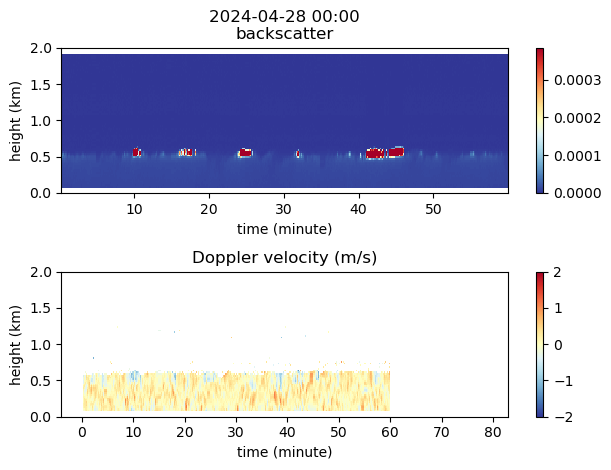

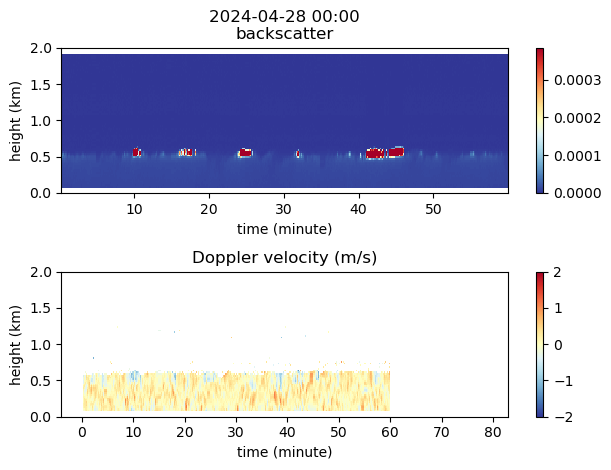

In [17]:
# plot 1 chunk
show(epsi_tmp[ic,:])

fig = gcf()
clf()
pcolor_lidar_stare(fig, beams, LidarDt, bigind_file_start, bigind_file_end)
plot(1e4 * epsi_tmp[ic,:])
gcf()

In [19]:
# loop through first 36 chunks, load next file as data is needed

if false | true # do not rerun and clobber data!
# periodic buffer for data
nx = 4000 
nz = 80
# x = zeros(nx,nz) # Doppler vel, backscatter, etc.
# P = PeriodicMatrix( x )
# dtx = PeriodicVector( fill(DateTime(0), nx) )
beams = init_periodic_beams(nx, nz)

# TKE dissipation output data array
epsi_tmp = zeros(Float64, length(iens), nz) .- 5 # dissipation for chunks; -5 is missing value

# fit quality metrics (saved alongside epsilon)
A_tmp       = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
se_A_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
nbins_tmp   = zeros(Int, length(iens), nz)
R2_tmp      = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
RMSE_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
A_lo_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
A_hi_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
epsi_lo_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
epsi_hi_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)

fig = gcf()

#ifile = 0
# bigind_file_end = 0 # forces initial read in loop
ifile_loaded = 0
# first file is ifile=30 for first chunk
subset_inds = collect(icall)[31:min(42, length(icall))]
# will skip to ic=35
show(subset_inds)

for ic in subset_inds
    ist = ists[ic]
    ien = iens[ic]

    # map this chunk to its start file
    ifile_needed = findlast(bigind_file_starts .<= ist)
    isnothing(ifile_needed) && error("No file contains ist=$ist")

    # initialize so first load can jump directly toward needed file
    if ifile_loaded == 0
        ifile_loaded = ifile_needed - 1
        bigind_file_end = 0
    end

    # load one or more files until this chunk [ist, ien] is fully available in beams
    while (ifile_loaded < ifile_needed) || (ien > bigind_file_end)
        ifile_loaded += 1
        if ifile_loaded > length(ff)
            error("Ran out of files while loading chunk ic=$ic, ist=$ist, ien=$ien")
        end

        bigind_file_start = bigind_file_starts[ifile_loaded]
        bigind_file_end   = bigind_file_ends[ifile_loaded]

        h  = read_lidar.read_streamlinexr_head(ff[ifile_loaded])
        bb = bigind_file_start:bigind_file_end
        read_streamlinexr_stare!(ff[ifile_loaded], h, beams, bb)

        println("\nic=$ic ifile_loaded=$ifile_loaded bigind_file=$bigind_file_start-$bigind_file_end")
    end
    print("$(ist)-$(ien) ") # subscript for chunk in beams is ist:ien, but data is loaded in bb
    # process chunk ic...

    # compute dissipation for the chunk
    # try # read a chunk, collocate wind and VN data
        # read_stare_chunk organizes and aligns lidar, motion, and wind data
        # should also work for periodic arrays in beams
        dt_chunk = LidarDt["dtime"][ist]
        Vn_use, used_vn_zero = vn_or_zero_for_chunk(dt_chunk, beams, Vn, ist, ien)
        dopplervel, pitch, roll, vn0, vn1, vn2, Ur, Vr, mdv = read_stare_chunk( dt_chunk, beams, Vn_use, UV, ist, ien )
        # recompute mdv - should be same as returned by read_stare_chunk
        valid_dv = isgoodnum.(dopplervel)
        jj = vec(all(valid_dv, dims=1))  # Bool vector over heights
        if any(jj)
            mdv = mean(dopplervel[:,jj], dims=2)[:] # mean of filled heights
        else
            mdv = fill(NaN, size(dopplervel, 1))
        end

        # vn0 experiment: ignore VectorNav motion (mdv stays only in w = dopplervel - mdv)
        pitch, roll, vn0, vn1, vn2 = force_vn0_motion(mdv)

        if any(isgoodnum.(Ur)) && any(isgoodnum.(Vr)) # there is wind data
            len = minimum((
                size(dopplervel, 1),
                length(pitch),
                length(roll),
                size(Ur, 1),
                size(Vr, 1),
                length(mdv),
            ))
            if len < 3
                epsi_tmp[ic, :] .= -3
                nbins_tmp[ic, :] .= 0
                continue
            end

            w = dopplervel[1:len, :] .- mdv[1:len]
            D2bin, rhobin, A_fit, noise, R2_fit, RMSE_fit, nbins_fit, se_A_fit, A_ci_lo, A_ci_hi, epsi_ci_lo, epsi_ci_hi = 
                D2_rho_stare_qc(w, pitch[1:len]*pi/180, roll[1:len]*pi/180, Ur[1:len, :], Vr[1:len, :])

            # metrics are informational only; no gating of epsilon results
            A_tmp[ic, :] .= A_fit
            se_A_tmp[ic, :] .= se_A_fit
            nbins_tmp[ic, :] .= nbins_fit
            R2_tmp[ic, :] .= R2_fit
            RMSE_tmp[ic, :] .= RMSE_fit
            A_lo_tmp[ic, :] .= A_ci_lo
            A_hi_tmp[ic, :] .= A_ci_hi
            epsi_lo_tmp[ic, :] .= epsi_ci_lo
            epsi_hi_tmp[ic, :] .= epsi_ci_hi

            for iz in eachindex(A_fit)
                a = A_fit[iz]
                if ismissing(a)
                    epsi_tmp[ic, iz] = -3   # code for missing/insufficient structure-function fit
                elseif a >= 0
                    epsi_tmp[ic, iz] = epsilon(a)
                else
                    epsi_tmp[ic, iz] = -1   # code for slope A <= 0
                end
            end
        else
            epsi_tmp[ic, :] .= -4           # code for missing wind (only this chunk)
            nbins_tmp[ic, :] .= 0
        end
    # catch
    #     epsi_tmp[ic,:] .= -5 # code for missing data, probably VN missing
    # end
end

# optional save: epsilon plus fit metrics
epsi = epsi_tmp
height = beams[:height]
A = A_tmp
se_A = se_A_tmp
nbins = nbins_tmp
savetime = Dates.format(now(), dateformat"yyyymmdd_HHMM")
# @save joinpath("epsilon_data","epsi_stare_chunks_vn0_r$(savetime).jld") epsi dtime_st dtime_en height A se_A nbins R2_tmp RMSE_tmp A_lo_tmp A_hi_tmp epsi_lo_tmp epsi_hi_tmp
end

[31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]
ic=31 ifile_loaded=5 bigind_file=12812-16014

ic=31 ifile_loaded=6 bigind_file=16015-19217
15749-16268 16269-16805 16806-17342 17343-17879 17880-18416 18417-18953 
ic=37 ifile_loaded=7 bigind_file=19218-22419
18954-19473 19474-20010 20011-20547 20548-21084 21085-21621 21622-22158 

"20260412_0953"

In [ ]:
# loop through first ALL chunks (967 files)
# finds file for each chunk and loads next file as data is needed
# complete run takes ~3 h

if false # | true # do not rerun and clobber data!
# periodic buffer for data
nx = 4000 
nz = 80
# x = zeros(nx,nz) # Doppler vel, backscatter, etc.
# P = PeriodicMatrix( x )
# dtx = PeriodicVector( fill(DateTime(0), nx) )
beams = init_periodic_beams(nx, nz)

# TKE dissipation output data array
epsi_tmp = zeros(Float64, length(iens), nz) .- 5 # dissipation for chunks; -5 is missing value

# fit quality metrics (saved alongside epsilon)
A_tmp       = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
se_A_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
nbins_tmp   = zeros(Int, length(iens), nz)
R2_tmp      = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
RMSE_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
A_lo_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
A_hi_tmp    = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
epsi_lo_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)
epsi_hi_tmp = Matrix{Union{Missing,Float64}}(missing, length(iens), nz)

fig = gcf()

#ifile = 0
# bigind_file_end = 0 # forces initial read in loop
ifile_loaded = 0
# first file is ifile=30 for first chunk
    
for ic in icall
    ist = ists[ic]
    ien = iens[ic]

    # map this chunk to its start file
    ifile_needed = findlast(bigind_file_starts .<= ist)
    isnothing(ifile_needed) && error("No file contains ist=$ist")

    # initialize so first load can jump directly toward needed file
    if ifile_loaded == 0
        ifile_loaded = ifile_needed - 1
        bigind_file_end = 0
    end

    # load one or more files until this chunk [ist, ien] is fully available in beams
    while (ifile_loaded < ifile_needed) || (ien > bigind_file_end)
        ifile_loaded += 1
        if ifile_loaded > length(ff)
            error("Ran out of files while loading chunk ic=$ic, ist=$ist, ien=$ien")
        end

        bigind_file_start = bigind_file_starts[ifile_loaded]
        bigind_file_end   = bigind_file_ends[ifile_loaded]

        h  = read_lidar.read_streamlinexr_head(ff[ifile_loaded])
        bb = bigind_file_start:bigind_file_end
        read_streamlinexr_stare!(ff[ifile_loaded], h, beams, bb)

        println("\nic=$ic ifile_loaded=$ifile_loaded bigind_file=$bigind_file_start-$bigind_file_end")
    end
    print("$(ist)-$(ien) ") # subscript for chunk in beams is ist:ien, but data is loaded in bb
    # process chunk ic...

    # compute dissipation for the chunk
    # try # read a chunk, collocate wind and VN data
        # read_stare_chunk organizes and aligns lidar, motion, and wind data
        # should also work for periodic arrays in beams
        dt_chunk = LidarDt["dtime"][ist]
        Vn_use, used_vn_zero = vn_or_zero_for_chunk(dt_chunk, beams, Vn, ist, ien)
        dopplervel, pitch, roll, vn0, vn1, vn2, Ur, Vr, mdv = read_stare_chunk( dt_chunk, beams, Vn_use, UV, ist, ien )
        # recompute mdv - should be same as returned by read_stare_chunk
        valid_dv = isgoodnum.(dopplervel)
        jj = vec(all(valid_dv, dims=1))  # Bool vector over heights
        if any(jj)
            mdv = mean(dopplervel[:,jj], dims=2)[:] # mean of filled heights
        else
            mdv = fill(NaN, size(dopplervel, 1))
        end

        # vn0 experiment: ignore VectorNav motion (mdv stays only in w = dopplervel - mdv)
        pitch, roll, vn0, vn1, vn2 = force_vn0_motion(mdv)

        if any(isgoodnum.(Ur)) && any(isgoodnum.(Vr)) # there is wind data
            len = minimum((
                size(dopplervel, 1),
                length(pitch),
                length(roll),
                size(Ur, 1),
                size(Vr, 1),
                length(mdv),
            ))
            if len < 3
                epsi_tmp[ic, :] .= -3
                nbins_tmp[ic, :] .= 0
                continue
            end

            w = dopplervel[1:len, :] .- mdv[1:len]
            D2bin, rhobin, A_fit, noise, R2_fit, RMSE_fit, nbins_fit, se_A_fit, A_ci_lo, A_ci_hi, epsi_ci_lo, epsi_ci_hi = 
                D2_rho_stare_qc(w, pitch[1:len]*pi/180, roll[1:len]*pi/180, Ur[1:len, :], Vr[1:len, :])

            # metrics are informational only; no gating of epsilon results
            A_tmp[ic, :] .= A_fit
            se_A_tmp[ic, :] .= se_A_fit
            nbins_tmp[ic, :] .= nbins_fit
            R2_tmp[ic, :] .= R2_fit
            RMSE_tmp[ic, :] .= RMSE_fit
            A_lo_tmp[ic, :] .= A_ci_lo
            A_hi_tmp[ic, :] .= A_ci_hi
            epsi_lo_tmp[ic, :] .= epsi_ci_lo
            epsi_hi_tmp[ic, :] .= epsi_ci_hi

            for iz in eachindex(A_fit)
                a = A_fit[iz]
                if ismissing(a)
                    epsi_tmp[ic, iz] = -3   # code for missing/insufficient structure-function fit
                elseif a >= 0
                    epsi_tmp[ic, iz] = epsilon(a)
                else
                    epsi_tmp[ic, iz] = -1   # code for slope A <= 0
                end
            end
        else
            epsi_tmp[ic, :] .= -4           # code for missing wind (only this chunk)
            nbins_tmp[ic, :] .= 0
        end
    # catch
    #     epsi_tmp[ic,:] .= -5 # code for missing data, probably VN missing
    # end
end

# optional save: epsilon plus fit metrics
epsi = epsi_tmp
height = beams[:height]
A = A_tmp
se_A = se_A_tmp
nbins = nbins_tmp
savetime = Dates.format(now(), dateformat"yyyymmdd_HHMM")
@save joinpath("epsilon_data","epsi_stare_chunks_vn0_r$(savetime).jld") epsi dtime_st dtime_en height A se_A nbins R2_tmp RMSE_tmp A_lo_tmp A_hi_tmp epsi_lo_tmp epsi_hi_tmp
end


ic=1 ifile_loaded=1 bigind_file=1-3202
1-243 244-780 781-1317 1318-1854 1855-2391 2392-2928 
ic=7 ifile_loaded=2 bigind_file=3203-6405
2929-3448 3449-3985 3986-4522 4523-5059 5060-5596 5597-6133 
ic=13 ifile_loaded=3 bigind_file=6406-9608
6134-6653 6654-7190 7191-7727 7728-8264 8265-8801 8802-9338 
ic=19 ifile_loaded=4 bigind_file=9609-12811
9339-9858 9859-10395 10396-10932 10933-11469 11470-12006 12007-12543 
ic=25 ifile_loaded=5 bigind_file=12812-16014
12544-13063 13064-13600 13601-14137 14138-14674 14675-15211 15212-15748 
ic=31 ifile_loaded=6 bigind_file=16015-19217
15749-16268 16269-16805 16806-17342 17343-17879 17880-18416 18417-18953 
ic=37 ifile_loaded=7 bigind_file=19218-22419
18954-19473 19474-20010 20011-20547 20548-21084 21085-21621 21622-22158 
ic=43 ifile_loaded=8 bigind_file=22420-25622
22159-22678 22679-23215 23216-23752 23753-24289 24290-24826 24827-25363 
ic=49 ifile_loaded=9 bigind_file=25623-28825
25364-25883 25884-26420 26421-26957 26958-27494 27495-28031 28032-28

R2:      n=274292 p50=0.8944444684641787 p90=0.990243923159619 p99=0.9980860293833586
RMSE:    n=274292 p50=0.007193339783035026 p90=0.05441324735632098 p99=0.39982533526540276
A CI w:  n=274292 p50=0.0019037686690782625 p90=0.05011592206589439 p99=0.9258655959754188
eps CI w:n=262426 p50=3.525138233223253e-5 p90=0.003380758103002893 p99=0.11112358652717558
(n-1)/(n-2): n=274348 p50=1.0666666666666667 p90=1.125 p99=2.0


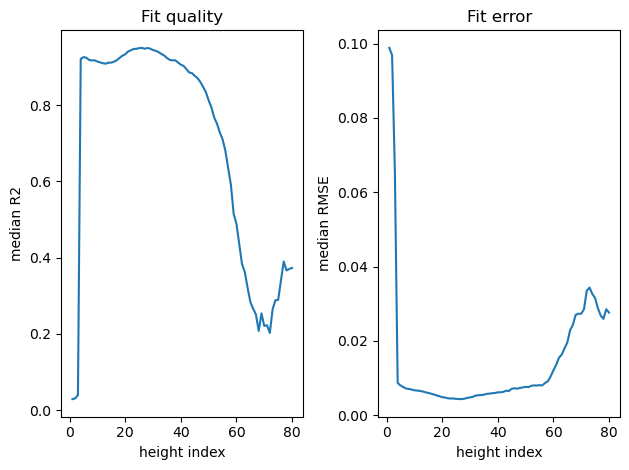

┌ Error: Error watching manifest
│   exception =
│    MethodError: no method matching (::NetCDF_jll.var"#make_wrapper_dict#make_wrapper_dict##1"{NetCDF_jll.var"#parse_wrapper_platform#parse_wrapper_platform##1"})(::String, ::Vector{String})
│    The function `make_wrapper_dict` exists, but no method is defined for this combination of argument types.
│    Stacktrace:
│     [1] top-level scope
│       @ ~/.julia/packages/JLLWrappers/m2Pjh/src/toplevel_generators.jl:167
│    Revise evaluation error at /Users/deszoeks/.julia/packages/JLLWrappers/m2Pjh/src/toplevel_generators.jl:167
│    
│    Stacktrace:
│     [1] methods_by_execution!(interp::JuliaInterpreter.NonRecursiveInterpreter, exinfo::Revise.ExInfo, mod::Module, ex::Expr; mode::Symbol, disablebp::Bool, always_rethrow::Bool, kwargs::@Kwargs{})
│       @ Revise ~/.julia/packages/Revise/HiWo5/src/lowered.jl:272
└ @ Revise ~/.julia/packages/Revise/HiWo5/src/pkgs.jl:478
┌ Error: Error watching manifest
│   exception =
│    MethodError: 

In [ ]:
# compact fit-metric diagnostics (non-gating)
required = (:A_tmp, :se_A_tmp, :nbins_tmp, :R2_tmp, :RMSE_tmp, :A_lo_tmp, :A_hi_tmp, :epsi_lo_tmp, :epsi_hi_tmp, :epsi_tmp)
missing_vars = [s for s in required if !isdefined(Main, s)]

if !isempty(missing_vars)
    @warn "Run the production loop cell first; missing variables" missing_vars
else
    # robust summary helper
    function finite_summary(X)
        vals = Float64[x for x in X if !ismissing(x) && isfinite(x)]
        if isempty(vals)
            return (n=0, p50=missing, p90=missing, p99=missing)
        end
        return (n=length(vals), p50=quantile(vals, 0.50), p90=quantile(vals, 0.90), p99=quantile(vals, 0.99))
    end

    # CI widths where both bounds are finite
    A_width = similar(A_lo_tmp, Union{Missing,Float64})
    epsi_width = similar(epsi_lo_tmp, Union{Missing,Float64})
    for i in eachindex(A_lo_tmp)
        if !ismissing(A_lo_tmp[i]) && !ismissing(A_hi_tmp[i]) && isfinite(A_lo_tmp[i]) && isfinite(A_hi_tmp[i])
            A_width[i] = A_hi_tmp[i] - A_lo_tmp[i]
        else
            A_width[i] = missing
        end
        if !ismissing(epsi_lo_tmp[i]) && !ismissing(epsi_hi_tmp[i]) && isfinite(epsi_lo_tmp[i]) && isfinite(epsi_hi_tmp[i])
            epsi_width[i] = epsi_hi_tmp[i] - epsi_lo_tmp[i]
        else
            epsi_width[i] = missing
        end
    end

    nfac = Matrix{Union{Missing,Float64}}(missing, size(nbins_tmp))
    for i in eachindex(nbins_tmp)
        n = nbins_tmp[i]
        if n > 2
            nfac[i] = (n - 1) / (n - 2)
        end
    end

    s_r2 = finite_summary(R2_tmp)
    s_rmse = finite_summary(RMSE_tmp)
    s_a_w = finite_summary(A_width)
    s_e_w = finite_summary(epsi_width)
    s_nfac = finite_summary(nfac)

    @printf("R2:      n=%d p50=%s p90=%s p99=%s\n", s_r2.n, string(s_r2.p50), string(s_r2.p90), string(s_r2.p99))
    @printf("RMSE:    n=%d p50=%s p90=%s p99=%s\n", s_rmse.n, string(s_rmse.p50), string(s_rmse.p90), string(s_rmse.p99))
    @printf("A CI w:  n=%d p50=%s p90=%s p99=%s\n", s_a_w.n, string(s_a_w.p50), string(s_a_w.p90), string(s_a_w.p99))
    @printf("eps CI w:n=%d p50=%s p90=%s p99=%s\n", s_e_w.n, string(s_e_w.p50), string(s_e_w.p90), string(s_e_w.p99))
    @printf("(n-1)/(n-2): n=%d p50=%s p90=%s p99=%s\n", s_nfac.n, string(s_nfac.p50), string(s_nfac.p90), string(s_nfac.p99))

    # quick profile medians over chunks by height index
    function col_median_missing(X)
        nz = size(X, 2)
        out = Vector{Union{Missing,Float64}}(missing, nz)
        for iz in 1:nz
            vals = Float64[x for x in X[:, iz] if !ismissing(x) && isfinite(x)]
            if !isempty(vals)
                out[iz] = median(vals)
            end
        end
        out
    end

    med_r2 = col_median_missing(R2_tmp)
    med_rmse = col_median_missing(RMSE_tmp)
    z = 1:length(med_r2)

    clf()
    subplot(1,2,1)
    plot(z, coalesce.(med_r2, NaN))
    xlabel("height index")
    ylabel("median R2")
    title("Fit quality")

    subplot(1,2,2)
    plot(z, coalesce.(med_rmse, NaN))
    xlabel("height index")
    ylabel("median RMSE")
    title("Fit error")
    tight_layout()
    # gcf()
end

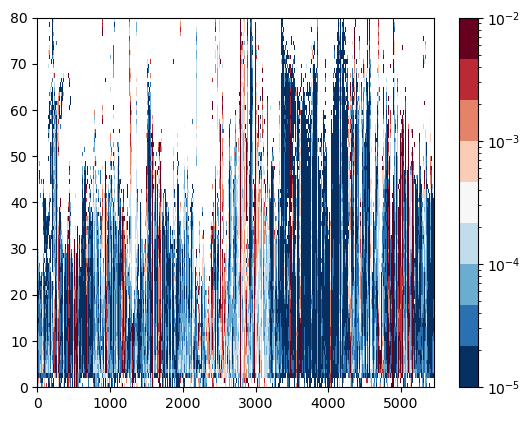

PyObject <matplotlib.colorbar.Colorbar object at 0x15903eb00>

In [23]:
# visualize the processed (tmp) data
idx = map(c-> c[1], findall( any(epsi_tmp .> 0, dims=2) ) ) # any chunk has data that is not missing
cmap = PyPlot.matplotlib.cm.get_cmap("RdBu_r", 9)
norm = PyPlot.matplotlib.colors.LogNorm(vmin=1e-5, vmax=1e-2)
pcolormesh( pd(max.(0,epsi_tmp[idx,:])),
    cmap=cmap, norm=norm )
colorbar()

In [25]:
# postproduction utility: load JLD and compute se_epsilon

"propagate slope uncertainty to epsilon uncertainty via first-order derivative"
function se_epsilon_from_A_seA(A, se_A)
    out = similar(A, Union{Missing,Float64})
    for i in eachindex(A)
        ai = A[i]
        sei = se_A[i]
        if ismissing(ai) || ismissing(sei)
            out[i] = missing
        elseif !isfinite(ai) || !isfinite(sei) || ai <= 0 || sei < 0
            out[i] = missing
        else
            out[i] = 1.5 * epsilon(ai) * (sei / ai)
        end
    end
    out
end

"tiny loader util: read output JLD and return se_epsilon + relative se"
function load_se_epsilon_jld(outfile)
    dat = load(outfile)

    A_in = haskey(dat, "A") ? dat["A"] : (haskey(dat, "A_tmp") ? dat["A_tmp"] : nothing)
    seA_in = haskey(dat, "se_A") ? dat["se_A"] : (haskey(dat, "se_A_tmp") ? dat["se_A_tmp"] : nothing)
    epsi_in = haskey(dat, "epsi") ? dat["epsi"] : nothing

    if isnothing(A_in) || isnothing(seA_in) || isnothing(epsi_in)
        error("Missing required keys. Need epsi and either (A, se_A) or (A_tmp, se_A_tmp).")
    end

    se_epsilon = se_epsilon_from_A_seA(A_in, seA_in)
    rel_se_epsilon = similar(se_epsilon, Union{Missing,Float64})
    for i in eachindex(se_epsilon)
        sei = se_epsilon[i]
        ei = epsi_in[i]
        if ismissing(sei) || ismissing(ei) || !isfinite(sei) || !isfinite(ei) || ei <= 0
            rel_se_epsilon[i] = missing
        else
            rel_se_epsilon[i] = sei / ei
        end
    end

    return (se_epsilon=se_epsilon, rel_se_epsilon=rel_se_epsilon, A=A_in, se_A=seA_in, epsi=epsi_in)
end

# call: use latest production output in epsilon_data/
latest_file = last(sort(filter(f -> startswith(f, "epsi_stare_chunks_vn0_r") && endswith(f, ".jld"), readdir("epsilon_data"))))
outfile = joinpath("epsilon_data", latest_file)
res = load_se_epsilon_jld(outfile)

finite_summary(X) = begin
    vals = Float64[x for x in X if !ismissing(x) && isfinite(x)]
    isempty(vals) ? (n=0, p50=missing, p90=missing, p99=missing) :
        (n=length(vals), p50=quantile(vals, 0.50), p90=quantile(vals, 0.90), p99=quantile(vals, 0.99))
end

s_se = finite_summary(res.se_epsilon)
s_rel = finite_summary(res.rel_se_epsilon)

@info "loaded" outfile
@printf("se_epsilon:      n=%d p50=%s p90=%s p99=%s\n", s_se.n, string(s_se.p50), string(s_se.p90), string(s_se.p99))
@printf("se_epsilon/epsi: n=%d p50=%s p90=%s p99=%s\n", s_rel.n, string(s_rel.p50), string(s_rel.p90), string(s_rel.p99))

┌ Info: loaded
└   outfile = "epsilon_data/epsi_stare_chunks_vn0_r20260412_1306.jld"


se_epsilon:      n=262426 p50=8.187787017123677e-6 p90=0.0007060797454197642 p99=0.01835684300330185
se_epsilon/epsi: n=262426 p50=0.1329192848961746 p90=0.840015522338505 p99=8.896511683147818


┌ Info: diagnostics file
└   outfile = "epsilon_data/epsi_stare_chunks_r20260410_1351.jld"


total_cells = 463440
negative_cells = 463440 (1.000000)
positive_cells = 0 (0.000000)
missing_cells = 0 (0.000000)
code -5 cells = 463440 (1.000000)
code -4 cells = 0 (0.000000)
code -3 cells = 0 (0.000000)
rows_with_any_positive = 0 / 5793 (0.000000)
positive in [3e-6, 3e-3] = 0 / 0 (0.000000)


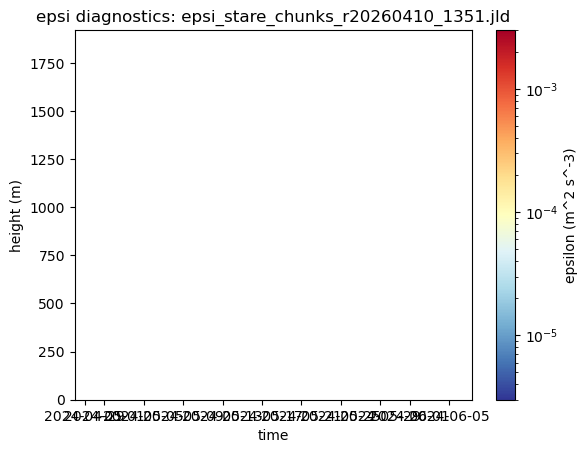

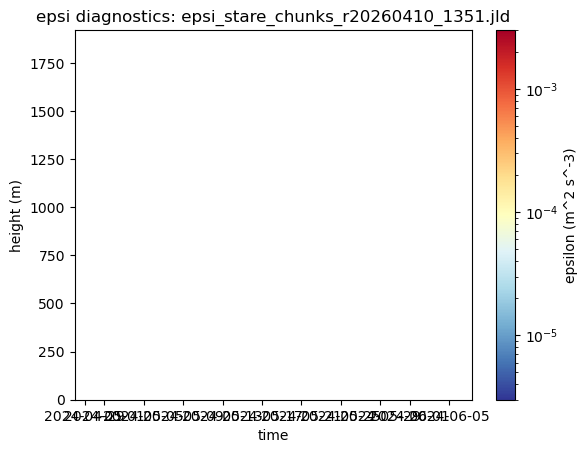

In [ ]:
#= diagnostics for the file just written above
outfile  = joinpath("epsilon_data", "epsi_stare_chunks_r$(savetime).jld")
@info "diagnostics file" outfile

dat = load(outfile)
epsi_diag = dat["epsi"]
dtime_diag = dat["dtime_st"]
height_diag = dat["height"]

# cell-wise fractions
total_cells = length(epsi_diag)
neg_cells = count(x -> !ismissing(x) && isfinite(x) && x < 0, epsi_diag)
pos_cells = count(x -> !ismissing(x) && isfinite(x) && x > 0, epsi_diag)
miss_cells = count(ismissing, epsi_diag)

@printf("total_cells = %d\n", total_cells)
@printf("negative_cells = %d (%.6f)\n", neg_cells, neg_cells / total_cells)
@printf("positive_cells = %d (%.6f)\n", pos_cells, pos_cells / total_cells)
@printf("missing_cells = %d (%.6f)\n", miss_cells, miss_cells / total_cells)

for code in (-5.0, -4.0, -3.0)
    ncode = count(x -> !ismissing(x) && isfinite(x) && x == code, epsi_diag)
    @printf("code %d cells = %d (%.6f)\n", Int(code), ncode, ncode / total_cells)
end

# row-wise "any positive epsilon" fraction
rows_with_any_positive = count(any((!ismissing).(row) .& isfinite.(row) .& (row .> 0)) for row in eachrow(epsi_diag))
nrows = size(epsi_diag, 1)
@printf("rows_with_any_positive = %d / %d (%.6f)\n", rows_with_any_positive, nrows, rows_with_any_positive / nrows)

# positive values in requested log range
valid_pos = Float64[x for x in epsi_diag if !ismissing(x) && isfinite(x) && x > 0]
inrange = count(x -> (3e-6 <= x <= 3e-3), valid_pos)
@printf("positive in [3e-6, 3e-3] = %d / %d (%.6f)\n", inrange, length(valid_pos), inrange / max(1, length(valid_pos)))

# log-scale time-height plot
eps_plot = Float64.(coalesce.(epsi_diag, NaN))
eps_plot[(.!isfinite.(eps_plot)) .| (eps_plot .<= 0)] .= NaN

clf()
norm = PyPlot.matplotlib.colors.LogNorm(vmin=3e-6, vmax=3e-3)
pcolormesh(dtime_diag, height_diag, pd(eps_plot[:, 1:length(height_diag)]), cmap=ColorMap("RdYlBu_r"), norm=norm)
cb = colorbar()
cb.set_label("epsilon (m^2 s^-3)")
ylabel("height (m)")
xlabel("time")
title("epsi diagnostics: $(basename(outfile))")
gcf()
=#